# EN3160 Image Processing & Computer Vision - Assignment 01
**Name:** Meedeniya M.M.H

**Index Number:** 230407K

**GitHub Repository:** https://github.com/manjarimeedeniya/EN3160-Assignment-01

In [14]:
# Importing required libraries
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt

## Question 1

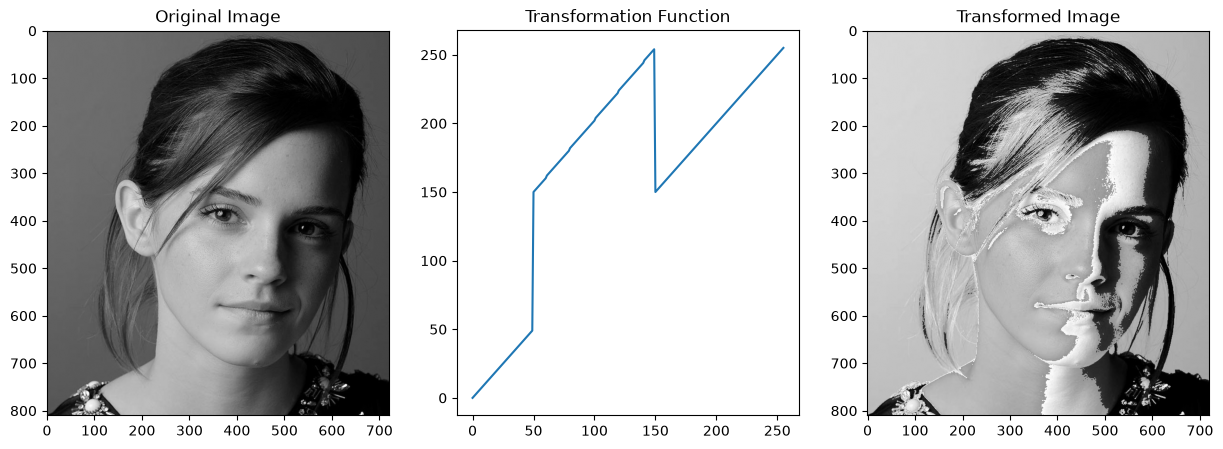

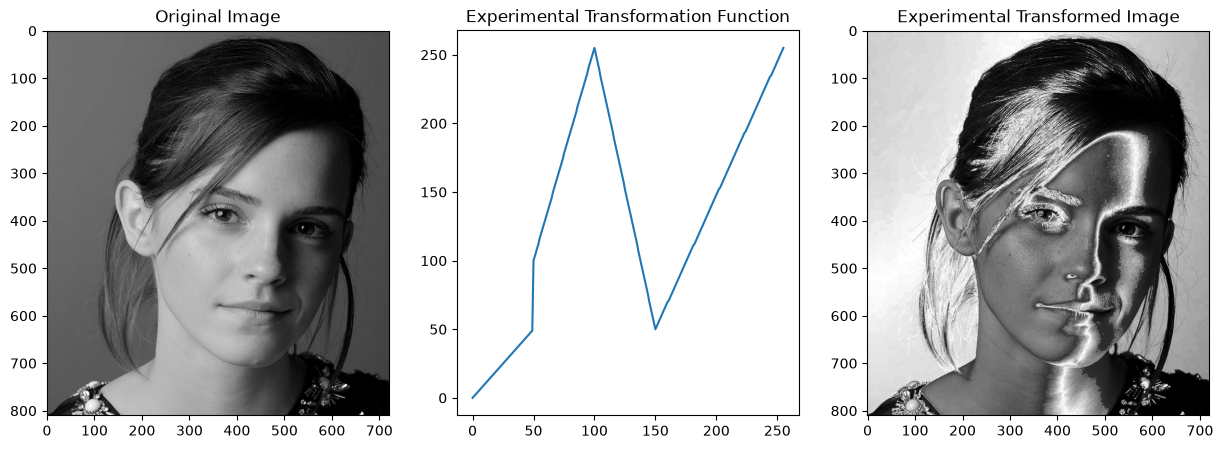

In [54]:
def intensity_transform(im,breakpoints):
    # Create an empty lookup table for intensities 0-255
    transform = np.zeros(256, dtype=np.uint8)

    # Generate each piecewise-linear segment
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x2 == x1:
            continue

        # Input intensity values in this segment
        x = np.arange(x1, x2 + 1)

        # Linear interpolation
        y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)

        transform[x] = np.round(y).astype(np.uint8)

    # Apply transformation using LUT
    transformed_image = cv.LUT(im, transform)

    return transformed_image, transform    



image1 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question1.jpeg',cv.IMREAD_GRAYSCALE)  # Read the first image in grayscale

bps = np.array([[0,0],[50,50],[50,150],[150,255],[150,150],[255,255]])  # Define breakpoints 
bps1 = np.array([[0,0],[50,50],[50,100],[100,255],[150,50],[255,255]])

image_transformed,transform=intensity_transform(image1, bps)
image_with_experimental_transform,transform1=intensity_transform(image1, bps1)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_transformed,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_with_experimental_transform,cmap='gray')
axes[2].set_title('Experimental Transformed Image') 
axes[1].plot(transform1)
axes[1].set_title('Experimental Transformation Function')    
plt.show()  # Show the plots

## Question 2

Detected Peaks -> Gray Matter: 149, White Matter: 169


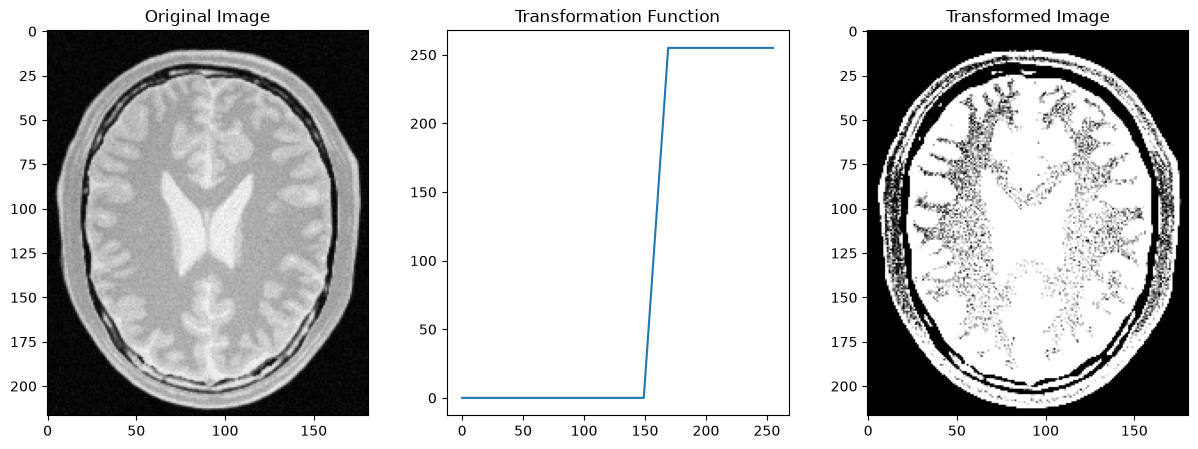

In [57]:
# 1. Load image
mri_image = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question2.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Calculate histogram (ignoring pure black background < 10)
hist = cv.calcHist([mri_image], [0], None, [256], [0, 256]).flatten()
hist[:10] = 0  # Ignore background zeros

# 3. Smooth histogram using a simple moving average to clear noise
kernel = np.ones(15) / 15
smoothed_hist = np.convolve(hist, kernel, mode='same')

# 4. Find tissue ranges by splitting histogram into mid and high intensity regions
# Gray matter peak is in the middle (e.g., 50 to 150)
gm_peak = np.argmax(smoothed_hist[50:150]) + 50

# White matter peak is in the higher region (e.g., 150 to 240)
wm_peak = np.argmax(smoothed_hist[150:240]) + 150

print(f"Detected Peaks -> Gray Matter: {gm_peak}, White Matter: {wm_peak}")

# 5. Build dynamic breakpoints automatically
# (a) White Matter Accentuation: Ramps up around white matter peak
bps_wm_auto = np.array([
    [0, 0],
    [gm_peak, 0],
    [wm_peak, 255],
    [255, 255]
])

# (b) Gray Matter Accentuation: Peak shape around gray matter intensity
bps_gm_auto = np.array([
    [0, 0],
    [gm_peak - 30, 0],
    [gm_peak, 255],
    [wm_peak, 0],
    [255, 0]
])

# Apply transformations using your existing function
img_wm, transform_wm = intensity_transform(mri_image, bps_wm_auto)
img_gm, transform_gm = intensity_transform(mri_image, bps_gm_auto)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(mri_image,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(img_wm,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform_wm)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

## Question 3

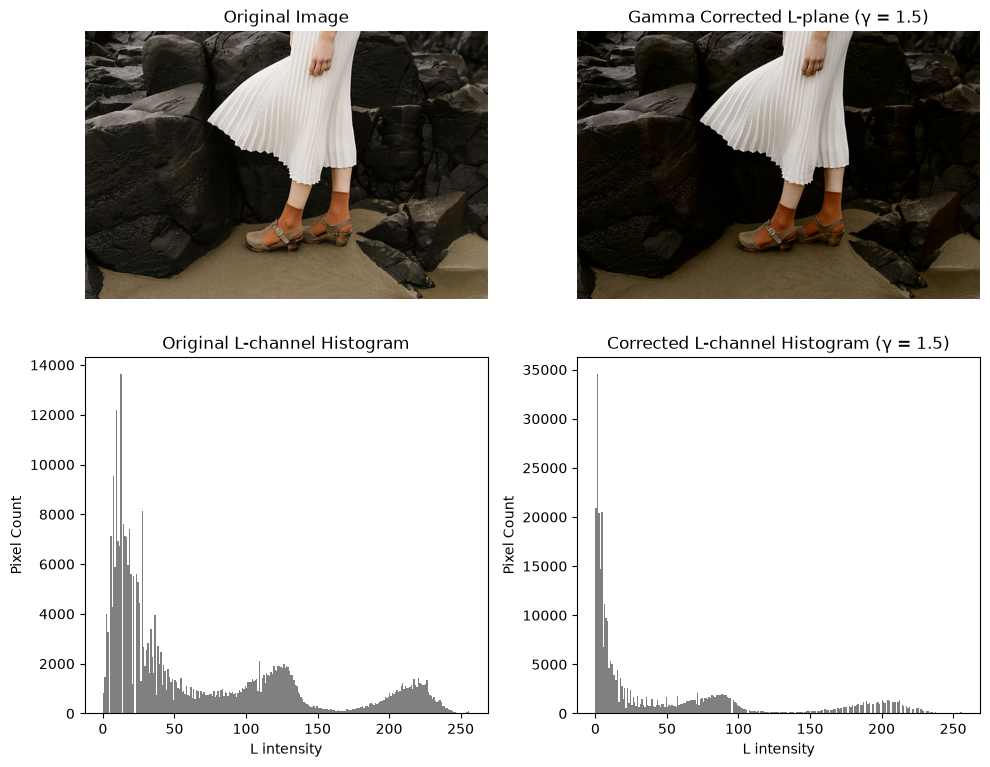

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read Image
img_bgr = cv2.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question3.jpeg')  # Replace with your image file path
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Convert to LAB color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# 3. Apply Gamma Correction to L-plane
gamma = 1.5  # Adjust gamma: < 1.0 brightens, > 1.0 darkens
L_normalized = L / 255.0
L_corrected = np.uint8(np.clip(np.power(L_normalized, gamma) * 255, 0, 255))

# 4. Merge back and convert to RGB
lab_corrected = cv2.merge([L_corrected, a, b])
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

# 5. Display Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Images
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected L-plane (γ = {gamma})")
axes[0, 1].axis('off')

# Histograms of L-plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title("Original L-channel Histogram")
axes[1, 0].set_xlabel("L intensity")
axes[1, 0].set_ylabel("Pixel Count")

axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 1].set_title(f"Corrected L-channel Histogram (γ = {gamma})")
axes[1, 1].set_xlabel("L intensity")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()